
# Task 4 – Reinforcement Learning: Tabular Q-Learning on a 5×5 Grid World

**CCS3611 Machine Learning – Group Portfolio**

This notebook implements a custom **5×5 Grid World** and a **tabular Q-learning** agent **from scratch** using only standard Python libraries (`numpy`, `matplotlib`, `pandas`). It satisfies the Task 4 brief by:

- defining the environment exactly as specified,
- implementing the Q-table, ε-greedy policy, and Q-learning update rule,
- training and evaluating the agent with a **pure greedy policy** (`ε = 0`),
- running two **controlled experiments**:
  1. **fast vs slow ε-decay** (exploration vs exploitation),
  2. **step penalty −1 vs 0** (the cost of time),
- plotting learning curves and printing the final greedy path.

To make the comparisons more defensible, the experiments below use **fixed random seeds** and report both a **representative run** and **aggregate results across 10 seeds**.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
MASTER_SEEDS = list(range(10))
REPRESENTATIVE_SEED = 3

# Plot style
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## 1. Environment Setup

The grid world matches the handout exactly:

| Element | Value |
|---|---|
| State space | 25 coordinates `(row, col)` from `(0,0)` to `(4,4)` |
| Action space | `0=Up`, `1=Down`, `2=Left`, `3=Right` |
| Start state | `(0,0)` |
| Goal state | `(4,4)` with reward `+10` and terminal transition |
| Trap states | `(1,1)`, `(2,3)`, `(3,1)` with reward `−10` and terminal transition |
| Standard step | reward `−1` by default |
| Boundary behaviour | illegal moves leave the agent in the same cell |


In [2]:

# Grid-world constants
GRID_SIZE = 5
START = (0, 0)
GOAL = (4, 4)
TRAPS = {(1, 1), (2, 3), (3, 1)}

ACTIONS = {
    0: (-1, 0),  # Up
    1: ( 1, 0),  # Down
    2: ( 0,-1),  # Left
    3: ( 0, 1),  # Right
}

ACTION_NAMES = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}
ACTION_ARROWS = {0: "↑", 1: "↓", 2: "←", 3: "→"}


def step(state, action, step_penalty=-1):
    """Environment transition function required by the brief.

    Parameters
    ----------
    state : tuple[int, int]
        Current coordinate (row, col).
    action : int
        One of {0, 1, 2, 3}.
    step_penalty : float
        Reward for any non-terminal move.

    Returns
    -------
    next_state : tuple[int, int]
    reward : float
    done : bool
    """
    dr, dc = ACTIONS[action]
    nr, nc = state[0] + dr, state[1] + dc

    # Off-grid moves leave the agent in the same cell
    if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE:
        next_state = (nr, nc)
    else:
        next_state = state

    if next_state == GOAL:
        return next_state, 10.0, True
    if next_state in TRAPS:
        return next_state, -10.0, True
    return next_state, float(step_penalty), False


# Sanity checks
assert step((0, 0), 0) == ((0, 0), -1.0, False)
assert step((0, 0), 2) == ((0, 0), -1.0, False)
assert step((3, 4), 1) == ((4, 4), 10.0, True)
assert step((0, 1), 1) == ((1, 1), -10.0, True)
assert step((2, 2), 3) == ((2, 3), -10.0, True)

print("Environment sanity checks passed.")


Environment sanity checks passed.



## 2. Q-Table and Agent Logic

The agent uses a `5 × 5 × 4` Q-table, where each cell stores the estimated return for a `(state, action)` pair.

The update rule is the standard one-step Q-learning rule:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \Big[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Big]
\]

An **ε-greedy** policy is used during training: with probability `ε` the agent explores; otherwise it exploits the highest-Q action. Ties are broken randomly.


In [3]:

def init_q_table():
    """Initialise a 25-state × 4-action Q-table to zero."""
    return np.zeros((GRID_SIZE, GRID_SIZE, len(ACTIONS)), dtype=float)


def epsilon_greedy(q_table, state, epsilon, rng):
    """Choose an action using ε-greedy exploration with random tie-breaking."""
    if rng.random() < epsilon:
        return int(rng.integers(len(ACTIONS)))

    q_values = q_table[state[0], state[1]]
    best_actions = np.flatnonzero(np.isclose(q_values, np.max(q_values), atol=1e-12, rtol=0))
    return int(rng.choice(best_actions))


def q_learning_update(q_table, state, action, reward, next_state, alpha, gamma, done):
    """Apply the tabular Q-learning update rule."""
    current_q = q_table[state[0], state[1], action]
    target = reward if done else reward + gamma * np.max(q_table[next_state[0], next_state[1]])
    q_table[state[0], state[1], action] += alpha * (target - current_q)


## 3. Training, Evaluation, and Analysis Helpers

In [4]:

def train_agent(
    seed=0,
    num_episodes=2000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.995,
    step_penalty=-1,
    max_steps=100,
):
    """Train the Q-learning agent and return full training traces."""
    rng = np.random.default_rng(seed)
    q_table = init_q_table()

    rewards_history = []
    steps_history = []
    success_history = []
    epsilon_history = []

    epsilon = eps_start

    for _ in range(num_episodes):
        state = START
        done = False
        total_reward = 0.0
        n_steps = 0

        while not done and n_steps < max_steps:
            action = epsilon_greedy(q_table, state, epsilon, rng)
            next_state, reward, done = step(state, action, step_penalty)
            q_learning_update(q_table, state, action, reward, next_state, alpha, gamma, done)

            state = next_state
            total_reward += reward
            n_steps += 1

        rewards_history.append(total_reward)
        steps_history.append(n_steps)
        success_history.append(int(state == GOAL))
        epsilon_history.append(epsilon)
        epsilon = max(eps_end, epsilon * eps_decay)

    return {
        "q_table": q_table,
        "rewards": np.array(rewards_history, dtype=float),
        "steps": np.array(steps_history, dtype=int),
        "success": np.array(success_history, dtype=int),
        "epsilon": np.array(epsilon_history, dtype=float),
        "config": {
            "seed": seed,
            "num_episodes": num_episodes,
            "alpha": alpha,
            "gamma": gamma,
            "eps_start": eps_start,
            "eps_end": eps_end,
            "eps_decay": eps_decay,
            "step_penalty": step_penalty,
            "max_steps": max_steps,
        },
    }


def evaluate_greedy(q_table, step_penalty=-1, max_steps=100):
    """Evaluate the learned policy with ε = 0 (pure exploitation)."""
    state = START
    path = [state]
    actions_taken = []
    total_reward = 0.0
    done = False

    while not done and len(actions_taken) < max_steps:
        action = int(np.argmax(q_table[state[0], state[1]]))
        next_state, reward, done = step(state, action, step_penalty)

        actions_taken.append(action)
        path.append(next_state)
        total_reward += reward
        state = next_state

    return {
        "path": path,
        "actions": actions_taken,
        "total_reward": total_reward,
        "success": state == GOAL,
    }


def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return np.array([])
    return np.convolve(values, np.ones(window) / window, mode="valid")


def first_episode_reaching_threshold(binary_series, threshold=0.8, window=100):
    """First episode where rolling success rate reaches the threshold."""
    rolled = moving_average(binary_series, window)
    idx = np.flatnonzero(rolled >= threshold)
    return int(idx[0] + window) if len(idx) else None


def mean_best_second_gap(q_table):
    """Average difference between the best and second-best action over non-terminal states."""
    gaps = []
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == GOAL or state in TRAPS:
                continue
            sorted_q = np.sort(q_table[r, c])
            gaps.append(sorted_q[-1] - sorted_q[-2])
    return float(np.mean(gaps))


def count_near_ties(q_table, atol=0.1):
    """Count extra actions whose Q-values are within atol of the best action."""
    ties = 0
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == GOAL or state in TRAPS:
                continue
            q_values = q_table[r, c]
            ties += max(0, int(np.sum(np.isclose(q_values, np.max(q_values), atol=atol, rtol=0))) - 1)
    return ties


def run_condition(seeds, **config):
    return [train_agent(seed=seed, **config) for seed in seeds]


def summarise_runs(runs):
    rows = []
    for run in runs:
        cfg = run["config"]
        greedy = evaluate_greedy(run["q_table"], step_penalty=cfg["step_penalty"], max_steps=cfg["max_steps"])
        rows.append({
            "seed": cfg["seed"],
            "mean_reward_last100": run["rewards"][-100:].mean(),
            "mean_steps_last100": run["steps"][-100:].mean(),
            "success_rate_last100": run["success"][-100:].mean(),
            "episode_to_80pct_success": first_episode_reaching_threshold(run["success"], threshold=0.80, window=100),
            "episode_to_95pct_success": first_episode_reaching_threshold(run["success"], threshold=0.95, window=100),
            "greedy_steps": len(greedy["path"]) - 1,
            "greedy_success": int(greedy["success"]),
            "greedy_total_reward": greedy["total_reward"],
            "mean_best_second_gap": mean_best_second_gap(run["q_table"]),
            "near_ties_total": count_near_ties(run["q_table"]),
        })
    return pd.DataFrame(rows)


def plot_learning_curves(runs_a, runs_b, label_a, label_b, title, window=50):
    """Plot mean reward curves with smoothed overlays across multiple seeds."""
    mean_a = np.mean(np.vstack([run["rewards"] for run in runs_a]), axis=0)
    mean_b = np.mean(np.vstack([run["rewards"] for run in runs_b]), axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(mean_a, alpha=0.18, linewidth=0.8, label=f"{label_a} (raw mean)")
    plt.plot(range(window - 1, len(mean_a)), moving_average(mean_a, window), linewidth=2.4, label=f"{label_a} (smoothed)")
    plt.plot(mean_b, alpha=0.18, linewidth=0.8, label=f"{label_b} (raw mean)")
    plt.plot(range(window - 1, len(mean_b)), moving_average(mean_b, window), linewidth=2.4, label=f"{label_b} (smoothed)")
    plt.xlabel("Episode")
    plt.ylabel("Total reward per episode")
    plt.title(title, fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_epsilon_schedules(config_a, config_b, label_a, label_b):
    eps_a = train_agent(seed=0, **config_a)["epsilon"]
    eps_b = train_agent(seed=0, **config_b)["epsilon"]

    plt.figure(figsize=(9, 4))
    plt.plot(eps_a, linewidth=2, label=label_a)
    plt.plot(eps_b, linewidth=2, label=label_b)
    plt.xlabel("Episode")
    plt.ylabel("ε")
    plt.title("Exploration schedules", fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_step_log(path, actions, total_reward):
    print(f"Total reward = {total_reward:.1f}")
    print(f"Path length   = {len(path) - 1} steps")
    print()
    for i, state in enumerate(path):
        tag = ""
        if state == START:
            tag = " [START]"
        elif state == GOAL:
            tag = " [GOAL]"
        elif state in TRAPS:
            tag = " [TRAP]"

        action_text = ""
        if i < len(actions):
            action_text = f"  ->  {ACTION_NAMES[actions[i]]}"

        print(f"Step {i:>2}: {state}{tag}{action_text}")


def print_visual_array(path):
    print()
    for step_idx, agent_pos in enumerate(path):
        label = "START" if step_idx == 0 else f"Step {step_idx}"
        if agent_pos == GOAL:
            label += " - GOAL REACHED"
        print(label)
        for r in range(GRID_SIZE):
            row = []
            for c in range(GRID_SIZE):
                pos = (r, c)
                if pos == agent_pos:
                    row.append("A")
                elif pos == GOAL:
                    row.append("G")
                elif pos in TRAPS:
                    row.append("T")
                elif pos == START:
                    row.append("S")
                else:
                    row.append(".")
            print(" ".join(row))
        print()


def visualise_grid_path(path, title):
    fig, ax = plt.subplots(figsize=(5.3, 5.3))
    ax.set_title(title, fontweight="bold")

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            color = "#f5f5f5"
            if state == START:
                color = "#dbeafe"
            if state == GOAL:
                color = "#dcfce7"
            if state in TRAPS:
                color = "#fee2e2"

            y = GRID_SIZE - 1 - r
            ax.add_patch(plt.Rectangle((c, y), 1, 1, facecolor=color, edgecolor="black", linewidth=1.2))

            if state == START:
                ax.text(c + 0.5, y + 0.5, "S", ha="center", va="center", fontsize=14, fontweight="bold")
            elif state == GOAL:
                ax.text(c + 0.5, y + 0.5, "★", ha="center", va="center", fontsize=16, fontweight="bold")
            elif state in TRAPS:
                ax.text(c + 0.5, y + 0.5, "X", ha="center", va="center", fontsize=14, fontweight="bold")

    for i in range(len(path) - 1):
        r1, c1 = path[i]
        r2, c2 = path[i + 1]
        ax.annotate(
            "",
            xy=(c2 + 0.5, GRID_SIZE - 1 - r2 + 0.5),
            xytext=(c1 + 0.5, GRID_SIZE - 1 - r1 + 0.5),
            arrowprops=dict(arrowstyle="-|>", lw=2),
        )

    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def visualise_policy(q_table, title):
    fig, ax = plt.subplots(figsize=(5.3, 5.3))
    ax.set_title(title, fontweight="bold")

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            color = "#f5f5f5"
            if state == START:
                color = "#dbeafe"
            if state == GOAL:
                color = "#dcfce7"
            if state in TRAPS:
                color = "#fee2e2"

            y = GRID_SIZE - 1 - r
            ax.add_patch(plt.Rectangle((c, y), 1, 1, facecolor=color, edgecolor="black", linewidth=1.2))

            if state == GOAL:
                ax.text(c + 0.5, y + 0.5, "★", ha="center", va="center", fontsize=16, fontweight="bold")
            elif state in TRAPS:
                ax.text(c + 0.5, y + 0.5, "X", ha="center", va="center", fontsize=14, fontweight="bold")
            else:
                best_action = int(np.argmax(q_table[r, c]))
                ax.text(c + 0.5, y + 0.5, ACTION_ARROWS[best_action], ha="center", va="center", fontsize=18, fontweight="bold")

    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## 4. Experiment 1 – Exploration vs Exploitation (Controlled Comparison)


All settings are held constant except **ε-decay**.

- **Fast decay:** `ε_decay = 0.99`
- **Slow decay:** `ε_decay = 0.999`

This is a fair controlled experiment because the grid, rewards, discount factor, learning rate, episode budget, and step limit are identical.


In [5]:

EXP1_COMMON = dict(
    num_episodes=2000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    step_penalty=-1,
    max_steps=100,
)

FAST_CFG = dict(**EXP1_COMMON, eps_decay=0.99)
SLOW_CFG = dict(**EXP1_COMMON, eps_decay=0.999)

fast_runs = run_condition(MASTER_SEEDS, **FAST_CFG)
slow_runs = run_condition(MASTER_SEEDS, **SLOW_CFG)

fast_summary = summarise_runs(fast_runs)
slow_summary = summarise_runs(slow_runs)

exp1_table = pd.DataFrame([
    {
        "Condition": "Fast decay (0.99)",
        "Mean reward, last 100": fast_summary["mean_reward_last100"].mean(),
        "Success rate, last 100": fast_summary["success_rate_last100"].mean(),
        "Episode to 80% success": fast_summary["episode_to_80pct_success"].mean(),
        "Runs reaching 95% success": int(fast_summary["episode_to_95pct_success"].notna().sum()),
        "Greedy path length": fast_summary["greedy_steps"].mean(),
        "Mean best-second gap": fast_summary["mean_best_second_gap"].mean(),
    },
    {
        "Condition": "Slow decay (0.999)",
        "Mean reward, last 100": slow_summary["mean_reward_last100"].mean(),
        "Success rate, last 100": slow_summary["success_rate_last100"].mean(),
        "Episode to 80% success": slow_summary["episode_to_80pct_success"].mean(),
        "Runs reaching 95% success": int(slow_summary["episode_to_95pct_success"].notna().sum()),
        "Greedy path length": slow_summary["greedy_steps"].mean(),
        "Mean best-second gap": slow_summary["mean_best_second_gap"].mean(),
    },
])

exp1_table.round(3)


,Condition,"Mean reward, last 100","Success rate, last 100",Episode to 80% success,Runs reaching 95% success,Greedy path length,Mean best-second gap
0,Fast decay (0.99),2.720,0.987,225.3,10,8.0,3.894
1,Slow decay (0.999),-0.677,0.841,1498.3,0,8.0,2.312


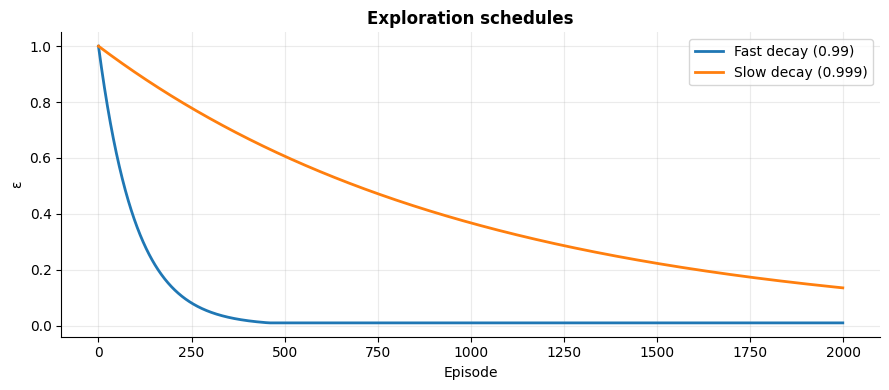

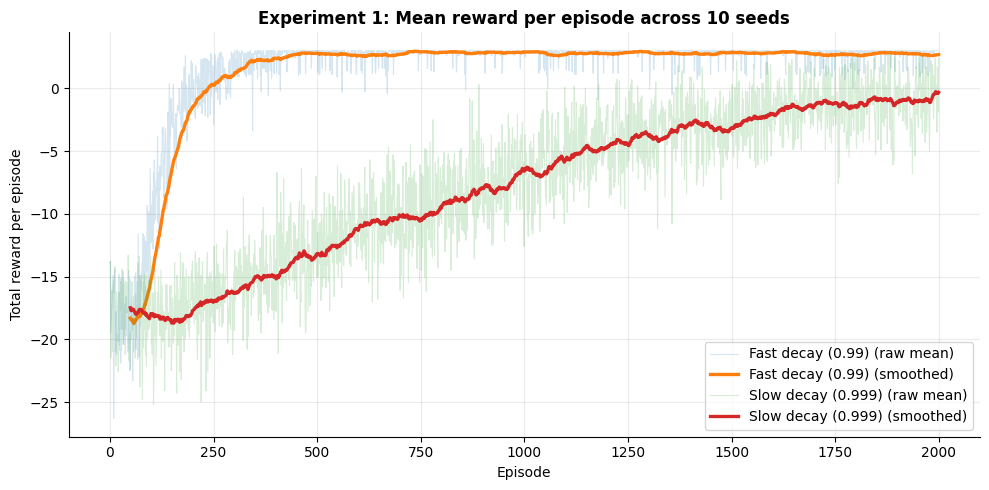

In [6]:

plot_epsilon_schedules(FAST_CFG, SLOW_CFG, "Fast decay (0.99)", "Slow decay (0.999)")
plot_learning_curves(
    fast_runs,
    slow_runs,
    "Fast decay (0.99)",
    "Slow decay (0.999)",
    title="Experiment 1: Mean reward per episode across 10 seeds",
    window=50,
)


In [7]:

fast_rep = train_agent(seed=REPRESENTATIVE_SEED, **FAST_CFG)
slow_rep = train_agent(seed=REPRESENTATIVE_SEED, **SLOW_CFG)

fast_eval = evaluate_greedy(fast_rep["q_table"], step_penalty=-1)
slow_eval = evaluate_greedy(slow_rep["q_table"], step_penalty=-1)

print("FAST DECAY — pure greedy evaluation (ε = 0)")
print_step_log(fast_eval["path"], fast_eval["actions"], fast_eval["total_reward"])

print("\nSLOW DECAY — pure greedy evaluation (ε = 0)")
print_step_log(slow_eval["path"], slow_eval["actions"], slow_eval["total_reward"])


FAST DECAY — pure greedy evaluation (ε = 0)
Total reward = 3.0
Path length   = 8 steps

Step  0: (0, 0) [START]  ->  Right
Step  1: (0, 1)  ->  Right
Step  2: (0, 2)  ->  Down
Step  3: (1, 2)  ->  Down
Step  4: (2, 2)  ->  Down
Step  5: (3, 2)  ->  Right
Step  6: (3, 3)  ->  Right
Step  7: (3, 4)  ->  Down
Step  8: (4, 4) [GOAL]

SLOW DECAY — pure greedy evaluation (ε = 0)
Total reward = 3.0
Path length   = 8 steps

Step  0: (0, 0) [START]  ->  Right
Step  1: (0, 1)  ->  Right
Step  2: (0, 2)  ->  Down
Step  3: (1, 2)  ->  Right
Step  4: (1, 3)  ->  Right
Step  5: (1, 4)  ->  Down
Step  6: (2, 4)  ->  Down
Step  7: (3, 4)  ->  Down
Step  8: (4, 4) [GOAL]


Representative greedy path (fast decay):

START
A . . . .
. T . . .
. . . T .
. T . . .
. . . . G

Step 1
S A . . .
. T . . .
. . . T .
. T . . .
. . . . G

Step 2
S . A . .
. T . . .
. . . T .
. T . . .
. . . . G

Step 3
S . . . .
. T A . .
. . . T .
. T . . .
. . . . G

Step 4
S . . . .
. T . . .
. . A T .
. T . . .
. . . . G

Step 5
S . . . .
. T . . .
. . . T .
. T A . .
. . . . G

Step 6
S . . . .
. T . . .
. . . T .
. T . A .
. . . . G

Step 7
S . . . .
. T . . .
. . . T .
. T . . A
. . . . G

Step 8 - GOAL REACHED
S . . . .
. T . . .
. . . T .
. T . . .
. . . . A



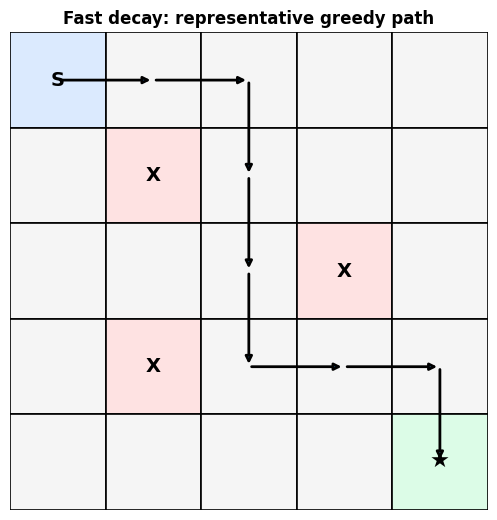

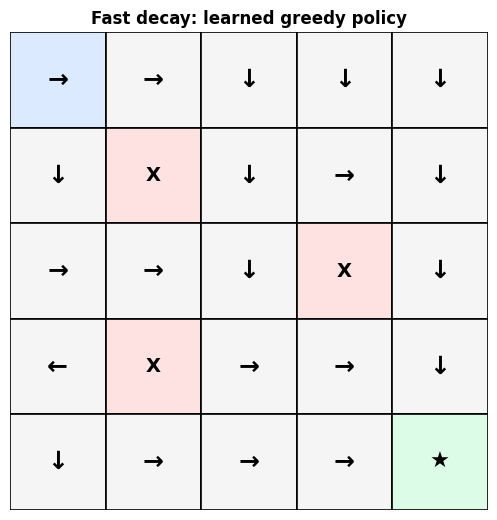

In [8]:

print("Representative greedy path (fast decay):")
print_visual_array(fast_eval["path"])

visualise_grid_path(fast_eval["path"], "Fast decay: representative greedy path")
visualise_policy(fast_rep["q_table"], "Fast decay: learned greedy policy")



### Experiment 1 Interpretation

The **fast ε-decay** agent learns much sooner because it stops taking costly exploratory actions earlier. Across the 10-seed aggregate, it reaches an **80% rolling success rate at about episode 225**, whereas the **slow ε-decay** condition only reaches the same level at roughly **episode 1498**. Fast decay also achieves a far higher late-training success rate.

Importantly, both conditions still produce an **8-step greedy path** during pure evaluation. That means the difference is not **final policy quality** but **training efficiency**. In this small deterministic grid, prolonged exploration is unnecessary and mostly harmful, so **fast decay is the better choice**.


## 5. Experiment 2 – The Cost of Time (Controlled Comparison)


All settings are held constant except the **standard step reward**.

- Condition A: step penalty `−1`
- Condition B: step penalty `0`

This comparison is more subtle than it first appears. Because `γ = 0.99`, the agent still weakly prefers receiving the terminal reward **earlier** even when the step reward is zero. So removing the step penalty does **not** eliminate time preference completely; it only makes that preference much weaker.


In [9]:

EXP2_COMMON = dict(
    num_episodes=2000,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.995,
    max_steps=100,
)

PEN_MINUS1_CFG = dict(**EXP2_COMMON, step_penalty=-1)
PEN_ZERO_CFG = dict(**EXP2_COMMON, step_penalty=0)

pen_minus1_runs = run_condition(MASTER_SEEDS, **PEN_MINUS1_CFG)
pen_zero_runs = run_condition(MASTER_SEEDS, **PEN_ZERO_CFG)

pen_minus1_summary = summarise_runs(pen_minus1_runs)
pen_zero_summary = summarise_runs(pen_zero_runs)

exp2_table = pd.DataFrame([
    {
        "Condition": "Step penalty = -1",
        "Success rate, last 100": pen_minus1_summary["success_rate_last100"].mean(),
        "Mean steps, last 100": pen_minus1_summary["mean_steps_last100"].mean(),
        "Episode to 80% success": pen_minus1_summary["episode_to_80pct_success"].mean(),
        "Greedy path length": pen_minus1_summary["greedy_steps"].mean(),
        "Mean best-second gap": pen_minus1_summary["mean_best_second_gap"].mean(),
        "Mean near-ties": pen_minus1_summary["near_ties_total"].mean(),
    },
    {
        "Condition": "Step penalty = 0",
        "Success rate, last 100": pen_zero_summary["success_rate_last100"].mean(),
        "Mean steps, last 100": pen_zero_summary["mean_steps_last100"].mean(),
        "Episode to 80% success": pen_zero_summary["episode_to_80pct_success"].mean(),
        "Greedy path length": pen_zero_summary["greedy_steps"].mean(),
        "Mean best-second gap": pen_zero_summary["mean_best_second_gap"].mean(),
        "Mean near-ties": pen_zero_summary["near_ties_total"].mean(),
    },
])

exp2_table.round(3)


,Condition,"Success rate, last 100","Mean steps, last 100",Episode to 80% success,Greedy path length,Mean best-second gap,Mean near-ties
0,Step penalty = -1,0.996,8.066,386.5,8.0,3.452,1.2
1,Step penalty = 0,0.995,8.050,344.3,8.0,2.143,12.8


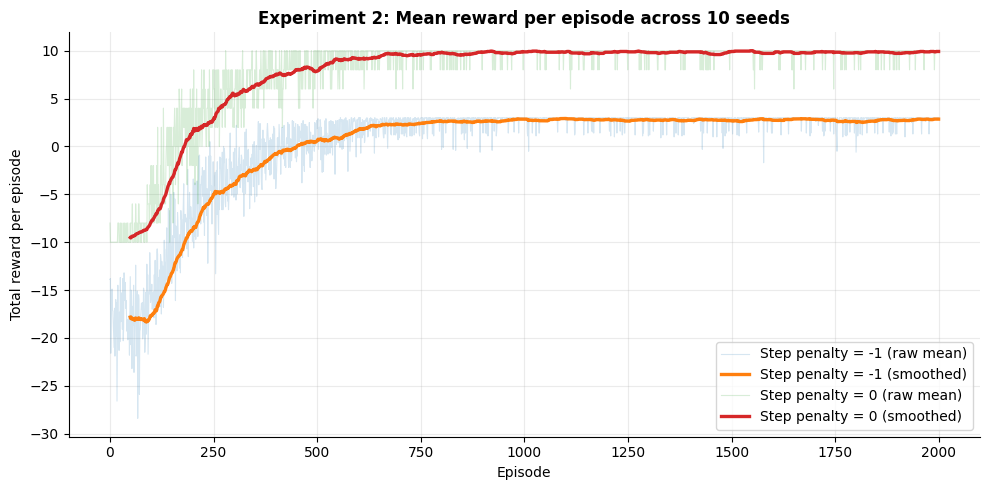

Important note:
The reward magnitudes above are NOT directly comparable across the two environments,
because the reward function itself changes. For this experiment, the cleaner comparisons
are success rate, greedy path length, action-value gaps, and number of near-ties.


In [10]:

# --- Success-rate learning curves (fair comparison) ---
def plot_success_curves(runs_a, runs_b, label_a, label_b, title, window=100):
    """Plot rolling success rate — comparable even when reward scales differ."""
    mean_a = np.mean(np.vstack([run["success"] for run in runs_a]), axis=0)
    mean_b = np.mean(np.vstack([run["success"] for run in runs_b]), axis=0)
    smoothed_a = moving_average(mean_a, window)
    smoothed_b = moving_average(mean_b, window)

    plt.figure(figsize=(10, 5))
    plt.plot(range(window - 1, len(mean_a)), smoothed_a, linewidth=2.4, label=label_a)
    plt.plot(range(window - 1, len(mean_b)), smoothed_b, linewidth=2.4, label=label_b)
    plt.xlabel("Episode")
    plt.ylabel("Rolling success rate")
    plt.title(title, fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_success_curves(
    pen_minus1_runs,
    pen_zero_runs,
    "Step penalty = -1",
    "Step penalty = 0",
    title="Experiment 2: Rolling success rate across 10 seeds",
    window=100,
)

# --- Steps-per-episode learning curves ---
mean_steps_m1 = np.mean(np.vstack([run["steps"] for run in pen_minus1_runs]), axis=0)
mean_steps_0  = np.mean(np.vstack([run["steps"] for run in pen_zero_runs]),  axis=0)

plt.figure(figsize=(10, 5))
plt.plot(range(49, len(mean_steps_m1)), moving_average(mean_steps_m1, 50),
         linewidth=2.4, label="Step penalty = -1")
plt.plot(range(49, len(mean_steps_0)),  moving_average(mean_steps_0,  50),
         linewidth=2.4, label="Step penalty = 0")
plt.xlabel("Episode")
plt.ylabel("Steps per episode (smoothed)")
plt.title("Experiment 2: Steps per episode across 10 seeds", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:

pen_minus1_rep = train_agent(seed=REPRESENTATIVE_SEED, **PEN_MINUS1_CFG)
pen_zero_rep = train_agent(seed=REPRESENTATIVE_SEED, **PEN_ZERO_CFG)

pen_minus1_eval = evaluate_greedy(pen_minus1_rep["q_table"], step_penalty=-1)
pen_zero_eval = evaluate_greedy(pen_zero_rep["q_table"], step_penalty=0)

print("STEP PENALTY = -1 — pure greedy evaluation")
print_step_log(pen_minus1_eval["path"], pen_minus1_eval["actions"], pen_minus1_eval["total_reward"])

print("\nSTEP PENALTY = 0 — pure greedy evaluation")
print_step_log(pen_zero_eval["path"], pen_zero_eval["actions"], pen_zero_eval["total_reward"])


STEP PENALTY = -1 — pure greedy evaluation
Total reward = 3.0
Path length   = 8 steps

Step  0: (0, 0) [START]  ->  Right
Step  1: (0, 1)  ->  Right
Step  2: (0, 2)  ->  Down
Step  3: (1, 2)  ->  Down
Step  4: (2, 2)  ->  Down
Step  5: (3, 2)  ->  Right
Step  6: (3, 3)  ->  Down
Step  7: (4, 3)  ->  Right
Step  8: (4, 4) [GOAL]

STEP PENALTY = 0 — pure greedy evaluation
Total reward = 10.0
Path length   = 8 steps

Step  0: (0, 0) [START]  ->  Down
Step  1: (1, 0)  ->  Down
Step  2: (2, 0)  ->  Right
Step  3: (2, 1)  ->  Right
Step  4: (2, 2)  ->  Down
Step  5: (3, 2)  ->  Down
Step  6: (4, 2)  ->  Right
Step  7: (4, 3)  ->  Right
Step  8: (4, 4) [GOAL]


Representative greedy path (step penalty = -1):

START
A . . . .
. T . . .
. . . T .
. T . . .
. . . . G

Step 1
S A . . .
. T . . .
. . . T .
. T . . .
. . . . G

Step 2
S . A . .
. T . . .
. . . T .
. T . . .
. . . . G

Step 3
S . . . .
. T A . .
. . . T .
. T . . .
. . . . G

Step 4
S . . . .
. T . . .
. . A T .
. T . . .
. . . . G

Step 5
S . . . .
. T . . .
. . . T .
. T A . .
. . . . G

Step 6
S . . . .
. T . . .
. . . T .
. T . A .
. . . . G

Step 7
S . . . .
. T . . .
. . . T .
. T . . .
. . . A G

Step 8 - GOAL REACHED
S . . . .
. T . . .
. . . T .
. T . . .
. . . . A



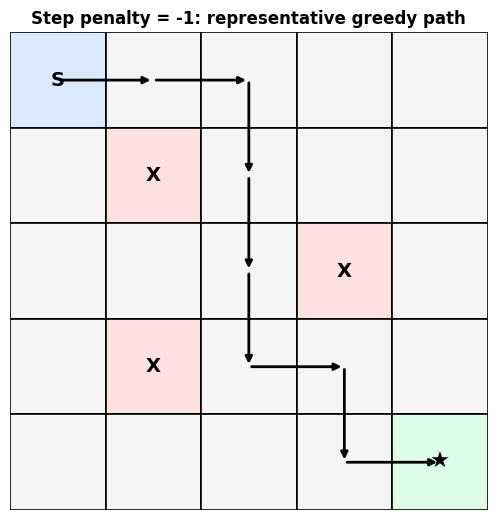

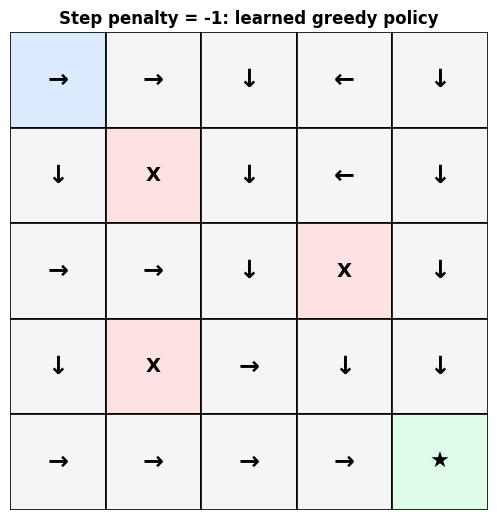

In [12]:

print("Representative greedy path (step penalty = -1):")
print_visual_array(pen_minus1_eval["path"])

visualise_grid_path(pen_minus1_eval["path"], "Step penalty = -1: representative greedy path")
visualise_policy(pen_minus1_rep["q_table"], "Step penalty = -1: learned greedy policy")


In [13]:

state_examples = [(0, 0), (0, 2), (2, 2), (3, 2)]

rows = []
for state in state_examples:
    if state in TRAPS or state == GOAL:
        continue
    q_m1 = pen_minus1_rep["q_table"][state[0], state[1]]
    q_0 = pen_zero_rep["q_table"][state[0], state[1]]

    rows.append({
        "State": state,
        "Best-second gap (pen = -1)": np.sort(q_m1)[-1] - np.sort(q_m1)[-2],
        "Best-second gap (pen = 0)": np.sort(q_0)[-1] - np.sort(q_0)[-2],
        "Greedy action (pen = -1)": ACTION_NAMES[int(np.argmax(q_m1))],
        "Greedy action (pen = 0)": ACTION_NAMES[int(np.argmax(q_0))],
    })

pd.DataFrame(rows).round(3)


,State,Best-second gap (pen = -1),Best-second gap (pen = 0),Greedy action (pen = -1),Greedy action (pen = 0)
0,"(0, 0)",1.975,0.858,Right,Down
1,"(0, 2)",1.883,1.284,Down,Down
2,"(2, 2)",3.652,1.086,Down,Down
3,"(3, 2)",1.906,1.148,Right,Down



### Experiment 2 Interpretation

The key finding is **not** that the agent suddenly forgets how to reach the goal. In fact, with `γ = 0.99`, the greedy policy still usually remains an **8-step path** because earlier reward is slightly better than delayed reward.

What changes is the **strength** of that preference:

- with step penalty `−1`, inefficient moves are punished immediately, so the Q-values develop **larger gaps** between good and bad actions;
- with step penalty `0`, the agent receives a much **weaker shaping signal**, so many states end up with **smaller action-value gaps** and **far more near-ties**.

Across the 10-seed aggregate, the mean best-vs-second-best action gap drops from about **3.45** to **2.14**, while the average number of near-ties rises sharply from about **1.2** to **12.8**. So removing the step penalty makes the learned policy **less sharply defined**, even though the final greedy route can still be short.



## 6. Conclusions

1. The custom tabular Q-learning agent successfully solves the 5×5 grid world and learns an optimal **8-step** greedy route to the treasure.
2. In this small deterministic environment, **fast ε-decay** is clearly better than slow decay because it reaches high success far earlier without hurting the final greedy policy.
3. Changing the step penalty from `−1` to `0` does **not** fully remove the preference for short paths because `γ = 0.99` still discounts delayed reward. However, it **does** reduce the sharpness of the learned policy by shrinking action-value gaps and creating many more near-ties.
4. The notebook is fully reproducible and uses no reinforcement-learning libraries, satisfying the implementation constraint of the brief.

### References

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292.
- Ng, A. Y., Harada, D., & Russell, S. (1999). Policy invariance under reward transformations: Theory and application to reward shaping. *ICML*.
